This file merges data from different files in preparation for analyses

In [1]:
import pandas as pd
import numpy as np
import os
d = os.getcwd()+"/"
PATH_RAW = f"{d}/../data"
PATH_DATA = f"{d}/../data"
PATH_OUTPUT = f"{d}/../output"

df = pd.read_csv(f"{PATH_DATA}/data_full.csv" , index_col='date', parse_dates=True)

We have a dataset constructed for analysis:

In [2]:
print(df.head(2))
print(df.columns)
print(df.shape)

            XIMP1001  XIMP1002  XIMP1003  XIMP1004  XIMP1005  XIMP1006  \
date                                                                     
2015-01-01       NaN       NaN       NaN       NaN       NaN       NaN   
2015-02-01       NaN       NaN       NaN       NaN       NaN       NaN   

            XIMP1007  XIMP1008  XIMP1009  XIMP1010  ...     UNTL9305  \
date                                                ...                
2015-01-01       NaN       NaN       NaN       NaN  ...  1527.528952   
2015-02-01       NaN       NaN       NaN       NaN  ...  1547.019815   

               UNTL9306     UNTL9307      UNTL9308       UNTL9309  \
date                                                                
2015-01-01  2638.613595  9255.949361  11427.284839  337465.967092   
2015-02-01  2650.099592  9243.623917  11720.094728  341293.498691   

                UNTL9310     UNTL9100    UNTL9101       UNTL9300     UNTL9301  
date                                                     

The dataset includes the output variable, GDP

<Axes: xlabel='date'>

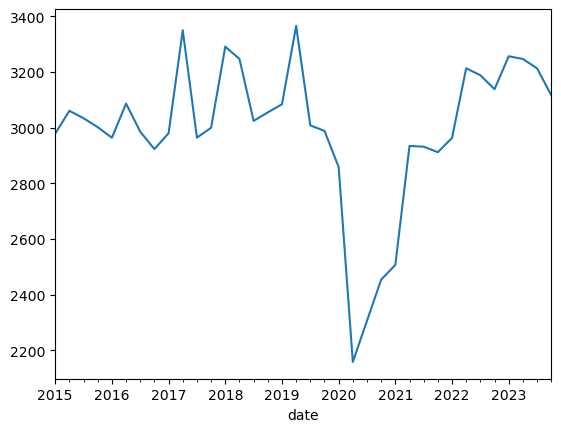

In [3]:
df['RGDP0000'].dropna().plot()

We wish to include **google trends** and **nighttime lights** data on our main data

First, let's remove the old variables

In [4]:
df[[ col for col in df.columns if "GTR" in col or "BMB" in col ]].tail(5)

,UBMB0000,UGTR0001,UGTR0010,UGTR0011,UGTR0012,UGTR0101,UGTR0017,UGTR0018,UGTR0019,UGTR0020,...,UGTR0097,UGTR0098,UGTR0099,UGTR0008,UGTR0100,UGTR0104,UGTR0009,UGTR0000,UGTR1000,UGTR1001
date,,,,,,,,,,,,,,,,,,,,,
2025-09-01,11358.881961,20.0,25.0,0.0,0.0,17.0,91.0,55.0,20.0,79.0,...,27.0,45.0,30.0,45.0,55.0,43.0,39.0,48.0,38.942308,41.256098
2025-10-01,11969.108872,21.0,11.0,1.0,NaN,13.0,94.0,67.0,7.0,70.0,...,24.0,40.0,29.0,18.0,67.0,36.0,36.0,48.0,37.215686,38.839506
2025-11-01,12403.084011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-12-01,10302.984993,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
data = df[[ col for col in df.columns if "GTR" not in col and "BMB" not in col ]]

The dataset now doesn't include these variables:

In [6]:
data[[ col for col in data.columns if "GTR" in col or "BMB" in col ]].tail(5)

""
date
2025-09-01
2025-10-01
2025-11-01
2025-12-01
2026-01-01


## Google Trends

In [12]:
df = pd.read_csv(f"{PATH_RAW}/gtrends.csv", parse_dates=True, index_col='date')
df.tail(5)

,gt_bahamas_hotels_united_states,gt_242_jobs_bahamas,gt_wendys_bahamas,gt_kfc_bahamas,gt_bamboo_shack_bahamas,gt_mcdonalds_bahamas,gt_apple_bahamas,gt_samsung_bahamas,gt_iphone_bahamas,gt_android_bahamas,...,gt_disney_world_bahamas,gt_rooms_to_go_bahamas,gt_fedex_bahamas,gt_700_wines_and_spirits_bahamas,gt_jobs_bahamas,gt_fresh_market_bahamas,gt_airbnb_bahamas_worldwide,gt_kraven_bahamas,gt_linkedin_bahamas,gt_bahamas_flights_united_states
date,,,,,,,,,,,,,,,,,,,,,
2025-09-01,21,24,100,91,65,33,73,26,52,18,...,18,0,42,38,58,16,44,53,40,48
2025-10-01,23,17,78,82,72,40,62,26,49,16,...,23,9,32,23,44,15,45,30,36,49
2025-11-01,25,12,85,93,63,64,79,30,56,17,...,28,0,41,24,43,24,51,39,42,56
2025-12-01,31,11,80,85,92,57,100,33,74,19,...,33,0,49,42,36,32,59,55,36,70
2026-01-01,40,10,68,72,78,28,80,26,62,19,...,41,3,35,9,46,16,64,20,43,98


In [13]:
df[df.index=='2025-01-01']

,gt_bahamas_hotels_united_states,gt_242_jobs_bahamas,gt_wendys_bahamas,gt_kfc_bahamas,gt_bamboo_shack_bahamas,gt_mcdonalds_bahamas,gt_apple_bahamas,gt_samsung_bahamas,gt_iphone_bahamas,gt_android_bahamas,...,gt_disney_world_bahamas,gt_rooms_to_go_bahamas,gt_fedex_bahamas,gt_700_wines_and_spirits_bahamas,gt_jobs_bahamas,gt_fresh_market_bahamas,gt_airbnb_bahamas_worldwide,gt_kraven_bahamas,gt_linkedin_bahamas,gt_bahamas_flights_united_states
date,,,,,,,,,,,,,,,,,,,,,
2025-01-01,40,21,67,76,85,42,70,26,49,15,...,23,0,41,16,55,19,52,74,33,92


Keep only data with enough observations

In [14]:
# Transform zeroes into np.nan
df = df.replace(0, np.nan)

# Keep only in the time period of the main database
df = df[df.index>=data.index.min()]

# drop columns with too many (75%) nan
df = df.dropna(axis=1, thresh=0.25 * len(df))

# Generate a column with the average
df['gt_all_mean'] = df.mean(axis=1)

In [15]:
df['gt_all_mean']

date
2015-01-01    37.745763
2015-02-01    36.839286
2015-03-01    36.950820
2015-04-01    38.967213
2015-05-01    38.677419
                ...    
2025-09-01    45.588235
2025-10-01    41.500000
2025-11-01    45.420290
2025-12-01    50.257143
2026-01-01    42.263889
Name: gt_all_mean, Length: 133, dtype: float64

<Axes: xlabel='date'>

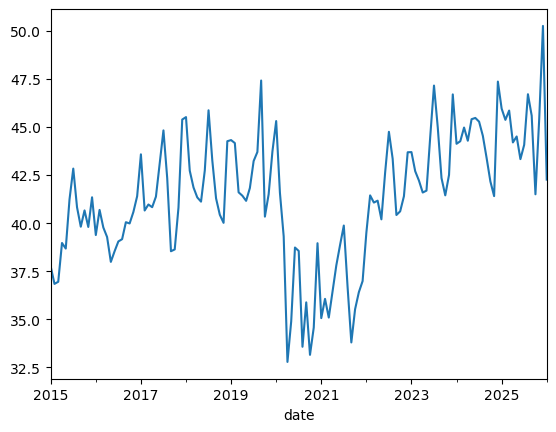

In [16]:
df['gt_all_mean'].plot()

In [17]:
data = pd.concat([ data , df] , axis=1).sort_index()
data.tail(5)

,XIMP1001,XIMP1002,XIMP1003,XIMP1004,XIMP1005,XIMP1006,XIMP1007,XIMP1008,XIMP1009,XIMP1010,...,gt_rooms_to_go_bahamas,gt_fedex_bahamas,gt_700_wines_and_spirits_bahamas,gt_jobs_bahamas,gt_fresh_market_bahamas,gt_airbnb_bahamas_worldwide,gt_kraven_bahamas,gt_linkedin_bahamas,gt_bahamas_flights_united_states,gt_all_mean
date,,,,,,,,,,,,,,,,,,,,,
2025-09-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,42.0,38.0,58.0,16.0,44.0,53.0,40.0,48.0,45.588235
2025-10-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,9.0,32.0,23.0,44.0,15.0,45.0,30.0,36.0,49.0,41.500000
2025-11-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,41.0,24.0,43.0,24.0,51.0,39.0,42.0,56.0,45.420290
2025-12-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,49.0,42.0,36.0,32.0,59.0,55.0,36.0,70.0,50.257143
2026-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,35.0,9.0,46.0,16.0,64.0,20.0,43.0,98.0,42.263889


## Nighttime Lights

In [18]:
df = pd.read_csv(f"{PATH_RAW}/blk_ntl.csv", parse_dates=True, index_col='date')
df.tail(5)

,NearNadir_Composite_Snow_Free,DNB_BRDF-Corrected_NTL
date,,
2025-08-01,11453.993915,NaN
2025-09-01,11358.881961,NaN
2025-10-01,11969.108872,NaN
2025-11-01,12403.084011,NaN
2025-12-01,10302.984993,10302.984993


We are only interested in one column.

<Axes: xlabel='date'>

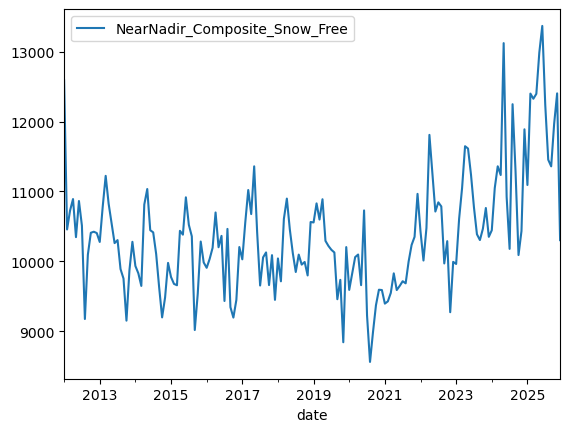

In [19]:
df = df[['NearNadir_Composite_Snow_Free']]
df.plot()

<Axes: xlabel='date'>

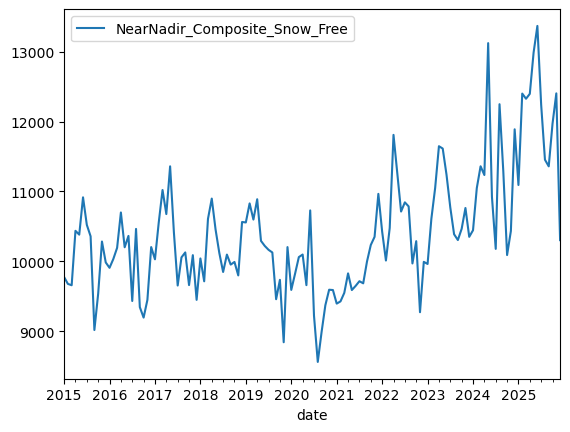

In [20]:
df = df[df.index>=data.index.min()]
df.plot()

In [21]:
data = pd.concat([ data , df] , axis=1).sort_index()
data.tail(5)

,XIMP1001,XIMP1002,XIMP1003,XIMP1004,XIMP1005,XIMP1006,XIMP1007,XIMP1008,XIMP1009,XIMP1010,...,gt_fedex_bahamas,gt_700_wines_and_spirits_bahamas,gt_jobs_bahamas,gt_fresh_market_bahamas,gt_airbnb_bahamas_worldwide,gt_kraven_bahamas,gt_linkedin_bahamas,gt_bahamas_flights_united_states,gt_all_mean,NearNadir_Composite_Snow_Free
date,,,,,,,,,,,,,,,,,,,,,
2025-09-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,42.0,38.0,58.0,16.0,44.0,53.0,40.0,48.0,45.588235,11358.881961
2025-10-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,32.0,23.0,44.0,15.0,45.0,30.0,36.0,49.0,41.500000,11969.108872
2025-11-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,41.0,24.0,43.0,24.0,51.0,39.0,42.0,56.0,45.420290,12403.084011
2025-12-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,49.0,42.0,36.0,32.0,59.0,55.0,36.0,70.0,50.257143,10302.984993
2026-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,35.0,9.0,46.0,16.0,64.0,20.0,43.0,98.0,42.263889,NaN


## Labels

This section changes the variable titles using the metadata

In [22]:
metadata = pd.read_csv(f"{PATH_DATA}\meta_full.csv")
metadata

<>:1: SyntaxWarning: invalid escape sequence '\m'
<>:1: SyntaxWarning: invalid escape sequence '\m'
C:\Users\guerr\AppData\Local\Temp\ipykernel_2356\3087221582.py:1: SyntaxWarning: invalid escape sequence '\m'
  metadata = pd.read_csv(f"{PATH_DATA}\meta_full.csv")


,type,series,name,ticket,freq,unstructured,nominal,block_g,block_s,block_r,block_l,months_lag,agg_method
0,R,gdp,NaN,RGDP0000,q,2,0,1,0,1,0,2,mean
1,M,cpi,NaN,MCPI0000,m,0,0,1,0,0,0,1,mean
2,X,imports_animal_and_vegetable_oils_and_fats,NaN,XIMP1001,q,0,1,1,0,1,0,0,mean
3,X,imports_beverages_and_tobacco,NaN,XIMP1002,q,0,1,1,0,1,0,0,mean
4,X,imports_chemicals,NaN,XIMP1003,q,0,1,1,0,1,0,0,mean
...,...,...,...,...,...,...,...,...,...,...,...,...,...
412,U,NearNadir_Composite_Snow_Free,NaN,UBMB0000,m,1,0,1,0,1,0,0,mean
413,U,gt_wendy_s_bs,NaN,UGTR0101,m,1,0,1,0,1,0,0,mean
414,U,gt_kelly_s_bs,NaN,UGTR0102,m,1,0,1,0,1,0,0,mean
415,U,gt_solomon_s_bs,NaN,UGTR0103,m,1,0,1,0,1,0,0,mean


If the variables in data do not exist in the metadata, we construct it

In [23]:
max_under_1000 = (
    metadata['ticket']
    .str.extract(r'UGTR(\d+)', expand=False)
    .astype(float)          # allows NaN safely
    .loc[lambda x: x < 1000]
    .max()
)

metadata.series = metadata.series.str.replace(" ", "_")
new_series = []
for col in [ col for col in data.columns if col not in list(metadata['series'].unique()) and col not in list(metadata['ticket'].unique()) ] :
    max_under_1000 = max_under_1000 + 1
    new_series.append(
        {'series': col,
         'freq': 'm' ,
         'ticket' : f'UGTR0{str(int(max_under_1000))}' ,
         'unstructured' : 1,
         'block_g' : 1,
         'block_s' : 0,
         'block_r' : 1 ,
         'block_l' : 0 , 
         'nominal' : 0 ,
         'months_lag' : 0,
         'agg_method' : 'mean'
         }
    )

print(new_series)
metadata = pd.concat( [ metadata, pd.DataFrame(new_series) ] )

[{'series': 'gt_bahamas_hotels_united_states', 'freq': 'm', 'ticket': 'UGTR0105', 'unstructured': 1, 'block_g': 1, 'block_s': 0, 'block_r': 1, 'block_l': 0, 'nominal': 0, 'months_lag': 0, 'agg_method': 'mean'}, {'series': 'gt_242_jobs_bahamas', 'freq': 'm', 'ticket': 'UGTR0106', 'unstructured': 1, 'block_g': 1, 'block_s': 0, 'block_r': 1, 'block_l': 0, 'nominal': 0, 'months_lag': 0, 'agg_method': 'mean'}, {'series': 'gt_wendys_bahamas', 'freq': 'm', 'ticket': 'UGTR0107', 'unstructured': 1, 'block_g': 1, 'block_s': 0, 'block_r': 1, 'block_l': 0, 'nominal': 0, 'months_lag': 0, 'agg_method': 'mean'}, {'series': 'gt_kfc_bahamas', 'freq': 'm', 'ticket': 'UGTR0108', 'unstructured': 1, 'block_g': 1, 'block_s': 0, 'block_r': 1, 'block_l': 0, 'nominal': 0, 'months_lag': 0, 'agg_method': 'mean'}, {'series': 'gt_bamboo_shack_bahamas', 'freq': 'm', 'ticket': 'UGTR0109', 'unstructured': 1, 'block_g': 1, 'block_s': 0, 'block_r': 1, 'block_l': 0, 'nominal': 0, 'months_lag': 0, 'agg_method': 'mean'}, 

In [24]:
for _, row in metadata.iterrows():
    series_name = row['series']
    ticket_name = row['ticket']
    if series_name in data.columns:
        data.rename(columns={series_name: ticket_name}, inplace=True)

In [25]:
data

,XIMP1001,XIMP1002,XIMP1003,XIMP1004,XIMP1005,XIMP1006,XIMP1007,XIMP1008,XIMP1009,XIMP1010,...,UGTR0169,UGTR0170,UGTR0171,UGTR0172,UGTR0173,UGTR0174,UGTR0175,UGTR0176,UGTR1001,UBMB0000
date,,,,,,,,,,,,,,,,,,,,,
2015-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,46.0,NaN,57.0,15.0,12.0,NaN,35.0,53.0,37.745763,9775.419815
2015-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,50.0,NaN,56.0,NaN,13.0,NaN,36.0,46.0,36.839286,9677.240394
2015-03-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,56.0,NaN,72.0,9.0,10.0,NaN,31.0,43.0,36.950820,9657.769108
2015-04-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,58.0,NaN,53.0,NaN,11.0,NaN,42.0,37.0,38.967213,10436.615860
2015-05-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,50.0,NaN,54.0,NaN,12.0,NaN,34.0,38.0,38.677419,10381.714964
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,42.0,38.0,58.0,16.0,44.0,53.0,40.0,48.0,45.588235,11358.881961
2025-10-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,32.0,23.0,44.0,15.0,45.0,30.0,36.0,49.0,41.500000,11969.108872
2025-11-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,41.0,24.0,43.0,24.0,51.0,39.0,42.0,56.0,45.420290,12403.084011


In [37]:
metadata[metadata['series'].str.contains('Snow')]

,type,series,name,ticket,freq,unstructured,nominal,block_g,block_s,block_r,block_l,months_lag,agg_method
412,U,NearNadir_Composite_Snow_Free,NaN,UBMB0000,m,1,0,1,0,1,0,0,mean


In [38]:
data[['UGTR1001', 'UBMB0000', 'RGDP0000']]

,UGTR1001,UBMB0000,RGDP0000
date,,,
2015-01-01,37.745763,9775.419815,NaN
2015-02-01,36.839286,9677.240394,NaN
2015-03-01,36.950820,9657.769108,2978.5
2015-04-01,38.967213,10436.615860,NaN
2015-05-01,38.677419,10381.714964,NaN
...,...,...,...
2025-09-01,45.588235,11358.881961,NaN
2025-10-01,41.500000,11969.108872,NaN
2025-11-01,45.420290,12403.084011,NaN


Lastly, to avoid issues, resample into monthly data

In [40]:
data = data.resample('MS').mean()
data

,XIMP1001,XIMP1002,XIMP1003,XIMP1004,XIMP1005,XIMP1006,XIMP1007,XIMP1008,XIMP1009,XIMP1010,...,UGTR0169,UGTR0170,UGTR0171,UGTR0172,UGTR0173,UGTR0174,UGTR0175,UGTR0176,UGTR1001,UBMB0000
date,,,,,,,,,,,,,,,,,,,,,
2015-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,46.0,NaN,57.0,15.0,12.0,NaN,35.0,53.0,37.745763,9775.419815
2015-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,50.0,NaN,56.0,NaN,13.0,NaN,36.0,46.0,36.839286,9677.240394
2015-03-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,56.0,NaN,72.0,9.0,10.0,NaN,31.0,43.0,36.950820,9657.769108
2015-04-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,58.0,NaN,53.0,NaN,11.0,NaN,42.0,37.0,38.967213,10436.615860
2015-05-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,50.0,NaN,54.0,NaN,12.0,NaN,34.0,38.0,38.677419,10381.714964
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,42.0,38.0,58.0,16.0,44.0,53.0,40.0,48.0,45.588235,11358.881961
2025-10-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,32.0,23.0,44.0,15.0,45.0,30.0,36.0,49.0,41.500000,11969.108872
2025-11-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,41.0,24.0,43.0,24.0,51.0,39.0,42.0,56.0,45.420290,12403.084011


Save the file

In [41]:
data.to_csv(f'{PATH_RAW}/data.csv')